In [9]:
import pandas as pd
import numpy as np

# ==============================
# Monthly backtest (3 months ahead)
# ==============================

HORIZON_MONTHS = 3  # predict liters 3 months into the future

# Load weekly processed dataset created in step 1
weekly_df = pd.read_csv("data/processed/weekly_beer_data.csv", parse_dates=["week"])

# Aggregate to monthly level (sum liters, sum rain, average temperature)
weekly_df["month_start"] = weekly_df["week"].dt.to_period("M").dt.to_timestamp()

monthly_df = (
    weekly_df
    .groupby(["month_start", "beer", "container"], as_index=False)
    .agg({
        "liters": "sum",
        "temp_mean": "mean",
        "rain_mm": "sum",
    })
)

monthly_df = monthly_df.sort_values(["beer", "container", "month_start"]).copy()
monthly_df["month"] = monthly_df["month_start"].dt.month.astype(int)
monthly_df["year"] = monthly_df["month_start"].dt.year.astype(int)

# Focus on a single beer + container for experimentation
TARGET_BEER = "Hoop Lager"
TARGET_CONTAINER = "Keg 20L"

filtered_df = monthly_df[
    (monthly_df["beer"] == TARGET_BEER) & (monthly_df["container"] == TARGET_CONTAINER)
].copy()

# If that combination is empty, fall back to beer-level aggregation only
if filtered_df.empty:
    print("No data for chosen beer+container; falling back to beer-level aggregation.")
    monthly_beer = (
        monthly_df
        .groupby(["month_start", "beer"], as_index=False)
        .agg({
            "liters": "sum",
            "temp_mean": "mean",
            "rain_mm": "sum",
        })
        .sort_values(["beer", "month_start"])
    )

    TARGET_CONTAINER = None
    filtered_df = monthly_beer[monthly_beer["beer"] == TARGET_BEER].copy()
    filtered_df["month"] = filtered_df["month_start"].dt.month.astype(int)
    filtered_df["year"] = filtered_df["month_start"].dt.year.astype(int)

# Handle any missing weather values
for col in ["temp_mean", "rain_mm"]:
    if col in filtered_df.columns:
        filtered_df[col] = filtered_df[col].ffill().bfill().fillna(0)

filtered_df = filtered_df.sort_values("month_start").copy()
filtered_df["time_index"] = np.arange(len(filtered_df), dtype=int)

# Lag features (past months)
MONTH_LAGS = [1, 2, 3, 6, 12]
usable_lags = [lag for lag in MONTH_LAGS if lag < len(filtered_df)]
for lag in usable_lags:
    filtered_df[f"lag_{lag}"] = filtered_df["liters"].shift(lag)

# Rolling summaries based on past data only
filtered_df["roll_mean_3"] = filtered_df["liters"].shift(1).rolling(3, min_periods=1).mean()
filtered_df["roll_mean_6"] = filtered_df["liters"].shift(1).rolling(6, min_periods=1).mean()

# Rolling volatility (standard deviation) based on past data only
filtered_df["roll_std_3"] = filtered_df["liters"].shift(1).rolling(3, min_periods=1).std()
filtered_df["roll_std_6"] = filtered_df["liters"].shift(1).rolling(6, min_periods=1).std()

# Seasonal terms (month-of-year)
angle = 2 * np.pi * (filtered_df["month"] / 12.0)
filtered_df["sin_moy"] = np.sin(angle)
filtered_df["cos_moy"] = np.cos(angle)

# Target: liters HORIZON_MONTHS into the future
filtered_df["y_future"] = filtered_df["liters"].shift(-HORIZON_MONTHS)

filtered_df = filtered_df.reset_index(drop=True)
print(
    f"Prepared monthly dataset for {TARGET_BEER} (container: {TARGET_CONTAINER}) with {len(filtered_df)} observations. "
    f"Horizon: {HORIZON_MONTHS} months. Usable lags: {usable_lags}"
)

Prepared monthly dataset for Hoop Lager (container: Keg 20L) with 52 observations. Horizon: 3 months. Usable lags: [1, 2, 3, 6, 12]


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Build feature set (including lags)
base_feature_cols = [
    "time_index",
    "month",
    "year",
    "temp_mean",
    "rain_mm",
    "sin_moy",
    "cos_moy",
    "roll_mean_3",
    "roll_mean_6",
    "roll_std_3",
    "roll_std_6",
]
lag_feature_cols = [c for c in filtered_df.columns if c.startswith("lag_")]
feature_cols = base_feature_cols + lag_feature_cols

# Drop rows without full lag history AND without future target available
# (last HORIZON_MONTHS rows have y_future = NaN)
df_model = filtered_df.dropna(subset=feature_cols + ["y_future"]).copy()

if len(df_model) < 18:
    raise ValueError(
        "Not enough monthly observations after creating lag features and a 3-month-ahead target. "
        "Try fewer lags or pick a series with longer history."
    )

X = df_model[feature_cols].values
y = df_model["y_future"].values

# Time-based train/test split: hold out the last few predictions
pred_month = df_model["month_start"]
target_month = pred_month + pd.offsets.MonthBegin(HORIZON_MONTHS)

test_size = max(6, min(12, len(df_model) // 4))  # 6-12 predictions held out
split_idx = len(df_model) - test_size

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
pred_month_test = pred_month.iloc[split_idx:]
target_month_test = target_month.iloc[split_idx:]

model = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    min_samples_leaf=2,
)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = float(np.sqrt(mse_test))
mae_test = float(mean_absolute_error(y_test, y_pred_test))

results_monthly = pd.DataFrame(
    {
        "pred_month": pred_month_test.values,
        "target_month": target_month_test.values,
        "actual": y_test,
        "predicted": y_pred_test,
    }
)

print(f"Monthly horizon: {HORIZON_MONTHS} months")
print(f"Features used: {len(feature_cols)} (lags: {len(lag_feature_cols)})")
print(f"Test  RMSE: {rmse_test:.1f} liters")
print(f"Test   MAE: {mae_test:.1f} liters")

Monthly horizon: 3 months
Features used: 14 (lags: 5)
Test  RMSE: 920.0 liters
Test   MAE: 726.8 liters


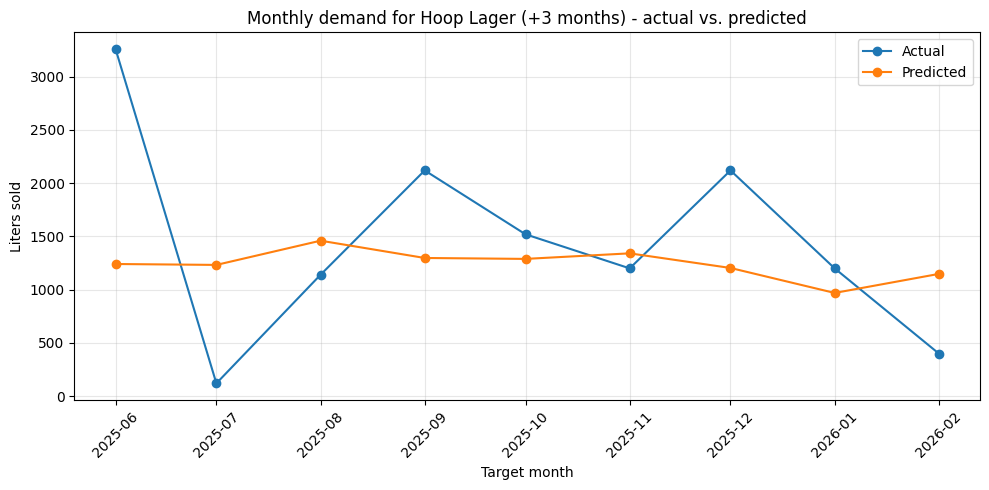

In [11]:
import matplotlib.pyplot as plt

# Plot actual vs. predicted for the target month (+HORIZON_MONTHS)
plt.figure(figsize=(10, 5))
plt.plot(results_monthly["target_month"], results_monthly["actual"], marker="o", label="Actual")
plt.plot(results_monthly["target_month"], results_monthly["predicted"], marker="o", label="Predicted")

plt.title(f"Monthly demand for {TARGET_BEER} (+{HORIZON_MONTHS} months) - actual vs. predicted")
plt.xlabel("Target month")
plt.ylabel("Liters sold")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Quick comparison helper (run after running XXX_weekly.ipynb too)

print("--- Monthly (3 months ahead) ---")
print("MAE:", float(np.mean(np.abs(results_monthly["actual"] - results_monthly["predicted"]))))
print("RMSE:", float(np.sqrt(np.mean((results_monthly["actual"] - results_monthly["predicted"]) ** 2))))

print("\nTip: run `XXX_weekly.ipynb` and compare its printed MAE/RMSE for +13 weeks.")

--- Monthly (3 months ahead) ---
MAE: 726.774509112287
RMSE: 920.024169527399

Tip: run `XXX_weekly.ipynb` and compare its printed MAE/RMSE for +13 weeks.
